# 3D RM-synthesis

In [1]:
from __future__ import annotations

import tempfile
from pathlib import Path

import astropy.io.fits as fits
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import zarr
from astropy.visualization import quantity_support

plt.rcParams["figure.dpi"] = 150

_ = quantity_support()
rng = np.random.default_rng(42)

We'll simulate a small Stokes Q/U cutout cube with a per-pixel Faraday rotation measure, write it to FITS with a dummy Stokes axis -- as in a typical ASKAP/EMU cutout cube (e.g. `image.restored.q.<field>.fits`) -- and read it back lazily with `rm_lite.utils.dask_io`.

As with the 1D example, we'll simulate RACS-all frequency coverage.

In [2]:
bw_low = 288
freqs = np.linspace(943.5 - bw_low / 2, 943.5 + bw_low / 2, 36) * u.MHz
freq_hz = freqs.to(u.Hz).value

Now build a small image with a single compact polarised source -- a 2D Gaussian blob, reusing the existing 1D `rm_lite.utils.fitting.gaussian` evaluated on a radial distance grid rather than writing a new 2D Gaussian from scratch -- on an otherwise unpolarised background. Keeping most of the field genuinely source-free matters below: the robust per-channel noise estimator needs mostly-empty sky to lock onto, same as it would on a real image.

In [3]:
from rm_lite.utils.fitting import gaussian
from rm_lite.utils.synthesis import faraday_simple_spectrum

ny, nx = 32, 32
y_grid, x_grid = np.mgrid[0:ny, 0:nx]
blob_y, blob_x = ny * 0.3, nx * 0.7
rm_map = 80.0 * (x_grid / nx - 0.5) * 2 + 40.0 * np.exp(
    -((x_grid - blob_x) ** 2 + (y_grid - blob_y) ** 2) / (2 * 4.0**2)
)

radius_grid = np.hypot(x_grid - blob_x, y_grid - blob_y)
frac_pol_map = gaussian(radius_grid, amplitude=0.6, mean=0.0, fwhm=6.0)

psi0_deg = 30.0
rms_noise = 0.03

stokes_q = np.empty((freq_hz.size, ny, nx), dtype=np.float32)
stokes_u = np.empty((freq_hz.size, ny, nx), dtype=np.float32)
for j in range(ny):
    for i in range(nx):
        complex_spectrum = faraday_simple_spectrum(
            freq_hz, frac_pol=frac_pol_map[j, i], psi0_deg=psi0_deg, rm_radm2=rm_map[j, i]
        )
        stokes_q[:, j, i] = complex_spectrum.real + rng.normal(0, rms_noise, freq_hz.size)
        stokes_u[:, j, i] = complex_spectrum.imag + rng.normal(0, rms_noise, freq_hz.size)

[Text(0.5, 1.0, 'Input (true) fractional polarisation')]

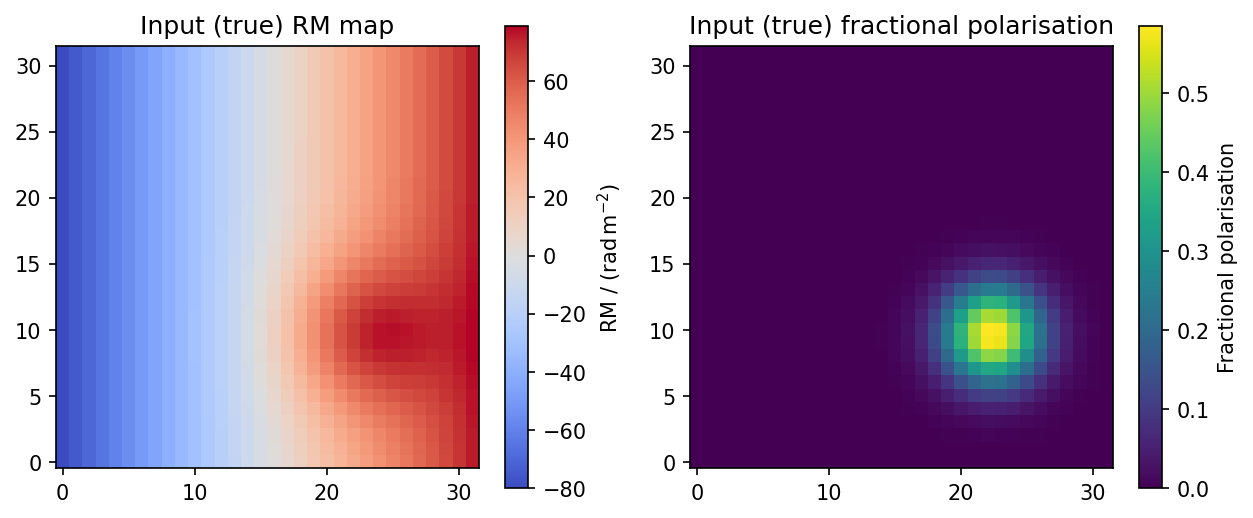

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
im1 = ax1.imshow(rm_map, origin="lower", cmap="coolwarm")
fig.colorbar(im1, ax=ax1, label=f"RM / ({u.rad / u.m**2:latex_inline})")
ax1.set(title="Input (true) RM map")
im2 = ax2.imshow(frac_pol_map, origin="lower")
fig.colorbar(im2, ax=ax2, label="Fractional polarisation")
ax2.set(title="Input (true) fractional polarisation")

Now write Stokes Q and U to separate FITS cubes, each with a degenerate leading Stokes axis (`NAXIS4 = 1`).

In [5]:
tmpdir = Path(tempfile.mkdtemp())


def write_stokes_fits(path: Path, data: np.ndarray, stokes: int) -> None:
    header = fits.Header()
    header["CTYPE1"] = "RA---SIN"
    header["CTYPE2"] = "DEC--SIN"
    header["CTYPE3"] = "FREQ"
    header["CRVAL3"] = freq_hz[0]
    header["CDELT3"] = float(np.diff(freq_hz)[0])
    header["CRPIX3"] = 1.0
    header["CUNIT3"] = "Hz"
    header["CTYPE4"] = "STOKES"
    header["CRVAL4"] = stokes
    header["CDELT4"] = 1.0
    header["CRPIX4"] = 1.0
    fits.PrimaryHDU(data=data[np.newaxis, ...], header=header).writeto(path, overwrite=True)


stokes_q_fits = tmpdir / "cutout.q.fits"
stokes_u_fits = tmpdir / "cutout.u.fits"
write_stokes_fits(stokes_q_fits, stokes_q, stokes=2)
write_stokes_fits(stokes_u_fits, stokes_u, stokes=3)

fits.getdata(stokes_q_fits).shape

(1, 36, 32, 32)

`read_fits_cube_dask` opens the cube with `memmap=True` and wraps it in a chunked `dask.array`, squeezing out the degenerate Stokes axis. The frequency axis is always kept whole in a chunk -- RM-synthesis needs every channel per pixel -- and the spatial chunk size is picked from a target per-chunk memory footprint, here set artificially small so multiple chunks show up in this small demo cube.

In [6]:
from rm_lite.utils.dask_io import read_fits_cube_dask

q_dask, q_header = read_fits_cube_dask(stokes_q_fits, target_chunk_bytes=32 * 1024)
u_dask, _ = read_fits_cube_dask(stokes_u_fits, target_chunk_bytes=32 * 1024)
q_dask

dask.array<array, shape=(36, 32, 32), dtype=>f4, chunksize=(36, 15, 15), chunktype=numpy.ndarray>

Before running RM-synthesis, estimate a robust per-channel noise directly from the cube with `estimate_channel_noise_mad` -- it takes the MAD-based standard deviation over every pixel in each channel plane, combined across Q and U the same way `compute_rmsynth_params` combines a per-channel error spectrum. This is what feeds `weight_arr` below and, in the RM-CLEAN notebook, the auto-mask/threshold.

In [7]:
from rm_lite.utils.dask_io import estimate_channel_noise_mad

channel_noise = estimate_channel_noise_mad(q_dask, u_dask)
weight_arr = 1.0 / channel_noise**2

print(f"true per-channel noise:      {rms_noise:.4f}")
print(f"estimated per-channel noise: {channel_noise.mean():.4f}")

true per-channel noise:      0.0300
estimated per-channel noise: 0.0333


Run 3D RM-synthesis with `rmsynth_3d`. This applies the same `rmsynth_nufft`/`get_rmsf_nufft` math used by the 1D/2D tools across the whole cube via `dask.array.map_blocks`, one call per spatial chunk.

We pin `phi_max_radm2`/`d_phi_radm2` to a small, coarse Faraday depth grid (just enough planes to cover our simulated RM range) so this demo runs quickly -- a real search would use finer sampling.

In [8]:
from rm_lite.tools_3d.rmsynth import rmsynth_3d

help(rmsynth_3d)

Help on function rmsynth_3d in module rm_lite.tools_3d.rmsynth:

rmsynth_3d(stokes_q: 'da.Array', stokes_u: 'da.Array', freq_arr_hz: 'NDArray[np.float64]', weight_arr: 'NDArray[np.float64] | None' = None, phi_max_radm2: 'float | None' = None, d_phi_radm2: 'float | None' = None, n_samples: 'float | None' = 10.0, log_level: 'int' = 30) -> 'RMSynth3DResults'
    Run RM-synthesis on chunked Stokes Q/U cubes.

    Args:
        stokes_q (da.Array): Stokes Q dask array, shape (n_freq, ny, nx),
            chunked spatially only (whole frequency axis per chunk).
        stokes_u (da.Array): Stokes U dask array, same shape/chunks as `stokes_q`.
        freq_arr_hz (NDArray[np.float64]): Frequency array in Hz.
        weight_arr (NDArray[np.float64] | None, optional): Per-channel weight
            array. Defaults to uniform weighting. Note this is a per-channel,
            not per-pixel, weight -- a per-pixel noise cube is not derived
            from the data here.
        phi_max_radm2 (flo

In [9]:
result = rmsynth_3d(
    q_dask, u_dask, freq_hz, weight_arr=weight_arr, phi_max_radm2=150.0, d_phi_radm2=10.0
)
result.fdf_dirty_cube

dask.array<_synth_block, shape=(31, 32, 32), dtype=complex128, chunksize=(31, 15, 15), chunktype=numpy.ndarray>

`rmsynth_3d` takes dask arrays, for callers who already have Q/U loaded (e.g. from zarr). When Q/U are plain FITS files on disk, `rmsynth_3d_from_fits` folds the `read_fits_cube_dask` calls above into `rmsynth_3d` itself, so the two files-to-lazy-cube reads don't need to be written out by hand each time.

In [10]:
from rm_lite.tools_3d.rmsynth import rmsynth_3d_from_fits

result_from_fits = rmsynth_3d_from_fits(
    stokes_q_fits,
    stokes_u_fits,
    freq_hz,
    weight_arr=weight_arr,
    phi_max_radm2=150.0,
    d_phi_radm2=10.0,
    target_chunk_bytes=32 * 1024,
)
np.allclose(result_from_fits.fdf_dirty_cube.compute(), result.fdf_dirty_cube.compute())

True

`fdf_dirty_cube` and `rmsf_cube` are still lazy -- nothing has been computed yet. Let's materialise the dirty FDF cube and look at the peak polarised intensity and recovered RM maps.

[Text(0.5, 1.0, 'Peak RM (recovered)')]

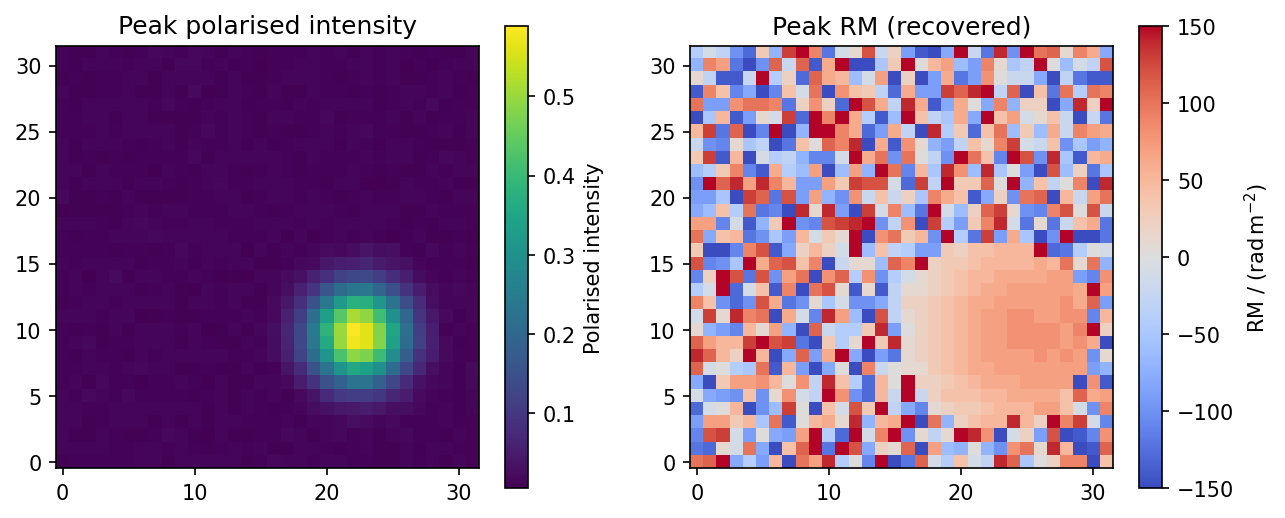

In [11]:
fdf_dirty_cube = result.fdf_dirty_cube.compute()
peak_pi_map = np.max(np.abs(fdf_dirty_cube), axis=0)
peak_idx_map = np.argmax(np.abs(fdf_dirty_cube), axis=0)
peak_rm_map = result.phi_arr_radm2[peak_idx_map]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
im1 = ax1.imshow(peak_pi_map, origin="lower")
fig.colorbar(im1, ax=ax1, label="Polarised intensity")
ax1.set(title="Peak polarised intensity")
im2 = ax2.imshow(peak_rm_map, origin="lower", cmap="coolwarm")
fig.colorbar(im2, ax=ax2, label=f"RM / ({u.rad / u.m**2:latex_inline})")
ax2.set(title="Peak RM (recovered)")

## Serialisation: zarr vs FITS

The dirty FDF and RMSF cubes are complex-valued, which matters for how they get written out:

- **zarr** supports complex128 natively, and `dask.array.to_zarr` writes chunk-by-chunk without ever materialising the full cube in memory -- the write scales with chunk size, not cube size, same as the computation itself.
- **FITS** has no native complex dtype, and `astropy.io.fits` needs a full in-memory array to write. Writing an FDF cube to FITS means computing the whole cube first, then splitting it into real/imaginary (or real/imaginary/polarised-intensity) HDUs -- the same convention classic RM-Tools uses for its `FDF_real_dirty.fits`/`FDF_im_dirty.fits`/`FDF_tot_dirty.fits` outputs.

zarr is the better fit for cube-sized outputs; FITS remains useful for interoperability with tools that expect it.

In [12]:
from rm_lite.utils.dask_io import write_zarr_group

zarr_store = tmpdir / "rmsynth3d.zarr"
write_zarr_group(
    zarr_store,
    {"fdf_dirty": result.fdf_dirty_cube, "rmsf": result.rmsf_cube},
)

group = zarr.open(zarr_store)
group["fdf_dirty"].shape, group["fdf_dirty"].dtype

((31, 32, 32), dtype('<c16'))

In [13]:
fits.PrimaryHDU(fdf_dirty_cube.real.astype(np.float32)).writeto(
    tmpdir / "FDF_real_dirty.fits", overwrite=True
)
fits.PrimaryHDU(fdf_dirty_cube.imag.astype(np.float32)).writeto(
    tmpdir / "FDF_im_dirty.fits", overwrite=True
)
fits.PrimaryHDU(np.abs(fdf_dirty_cube).astype(np.float32)).writeto(
    tmpdir / "FDF_tot_dirty.fits", overwrite=True
)

roundtrip = fits.getdata(tmpdir / "FDF_tot_dirty.fits")
np.allclose(roundtrip, np.abs(fdf_dirty_cube), atol=1e-5)

True

See the 3D RM-CLEAN page for deconvolving these dirty FDF/RMSF cubes.